In [29]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [30]:
# Part A: Understanding the Dataset
# Q1. Dataset Overview
# Loading the dataset
df = pd.read_csv("agriculture_yield_dataset.csv")

# Number of rows and columns
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# First 10 records
print("\nFirst 10 Records:")
print(df.head(10))

Shape of Dataset: (1500, 8)

Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5      

In [31]:
# Q2. Data Types and Missing Values
# Data types
print("Data Types:\n")
print(df.dtypes)

# Missing values

print("\nMissing Values:\n")
print(df.isnull().sum())

Data Types:

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [32]:
# Q3. Descriptive Statistics
# Summary statistics
stats = df.describe()
print(stats)

# Highest mean value

means = stats.loc['mean']
print("\nFeature with Highest Mean:")
print(means.idxmax(), "=", means.max())

# Highest standard deviation

stds = stats.loc['std']
print("\nFeature with Highest Standard Deviation:")
print(stds.idxmax(), "=", stds.max())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

Highest Mean Value and standard deviation is for
rainfall_mm



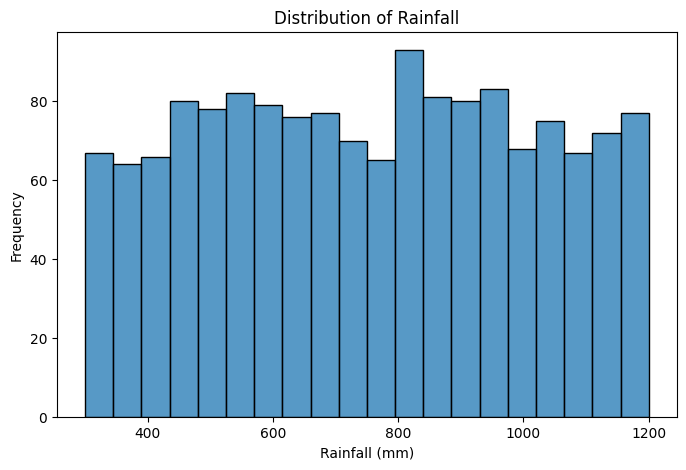

In [33]:
# Part B: Exploratory Data Analysis (EDA)
# Q4. Distribution Analysis
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='rainfall_mm',
    bins=20,

)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

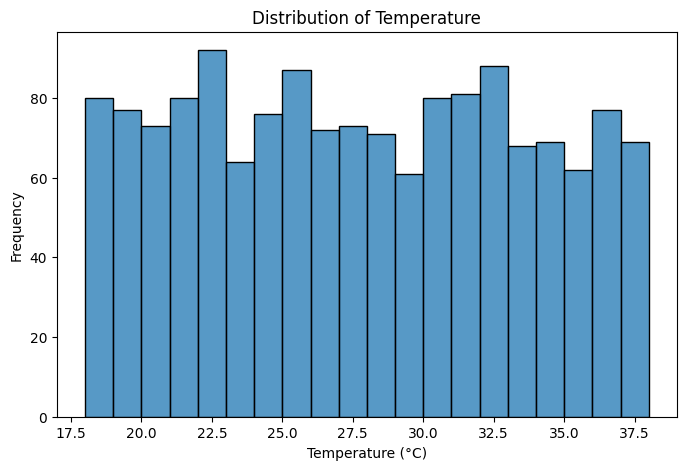

In [34]:
# temperature histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='temperature_c',
    bins=20,
    )

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

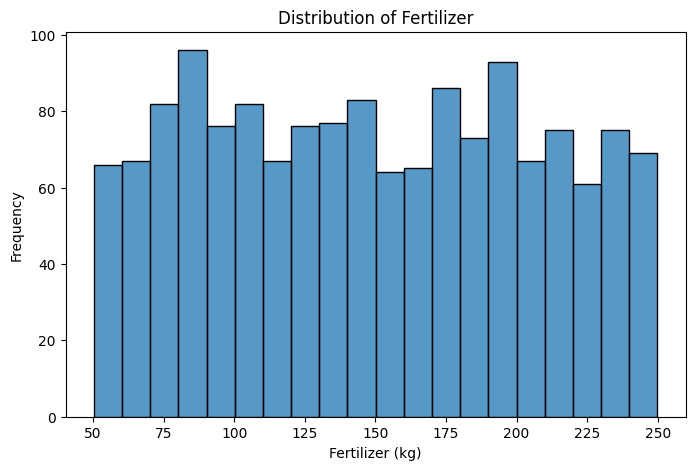

In [35]:
#fertilizer histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='fertilizer_kg',
    bins=20
)

plt.title("Distribution of Fertilizer")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")

plt.show()

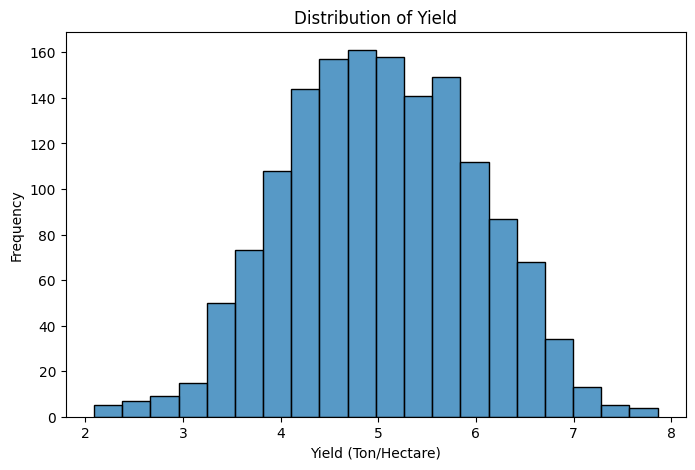

In [36]:
# Yield histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='yield_ton_per_hectare',
    bins=20,
)

plt.title("Distribution of Yield")
plt.xlabel("Yield (Ton/Hectare)")
plt.ylabel("Frequency")

plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


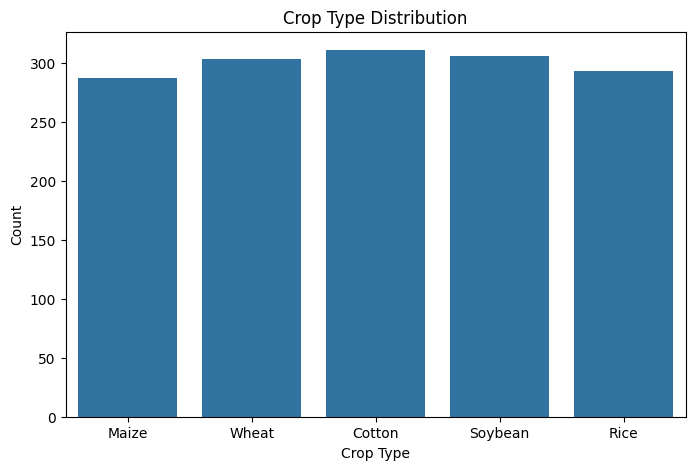


Most Frequent Crop:
Cotton


In [37]:
# Q5. Crop Type Analysis
# counting qunatity of each crop
print(df['crop_type'].value_counts())

#plotting bar chart
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='crop_type'
)

plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")

plt.show()

print("\nMost Frequent Crop:")
print(df['crop_type'].value_counts().idxmax())

Cotton crop appears most frequently.

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


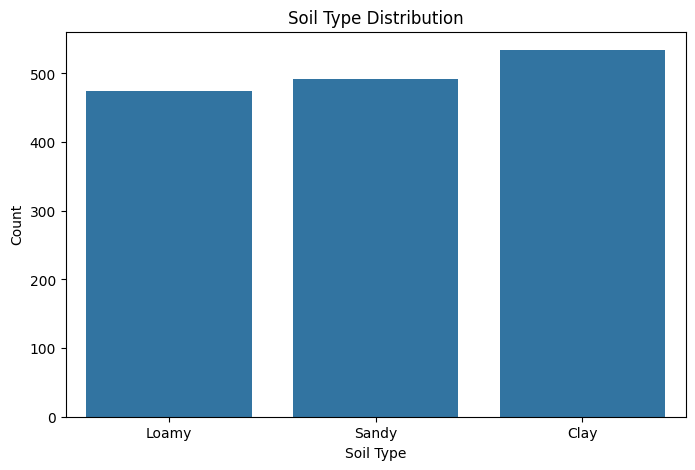


Most Common Soil:
Clay


In [38]:
# Q6. Soil Type Analysis
# counting quantity of types of soil
print(df['soil_type'].value_counts())

# plotting  bar chart
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='soil_type'
)

plt.title("Soil Type Distribution")
plt.xlabel("Soil Type")
plt.ylabel("Count")

plt.show()

print("\nMost Common Soil:")
print(df['soil_type'].value_counts().idxmax())

clay is the most common soil type.

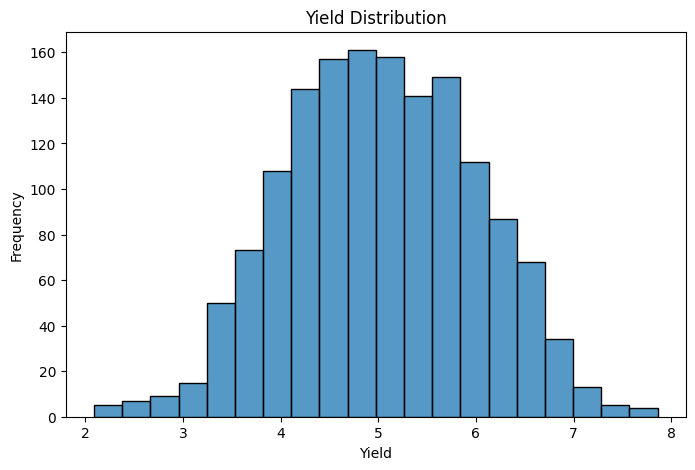

In [39]:
# Q7. Yield Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='yield_ton_per_hectare',
    bins=20,
)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

(a). Is it approximately normal?

Yes, the distribution is roughly normal and centered around 5.

(b). Any noticeable outliers?

No major outliers are visible.

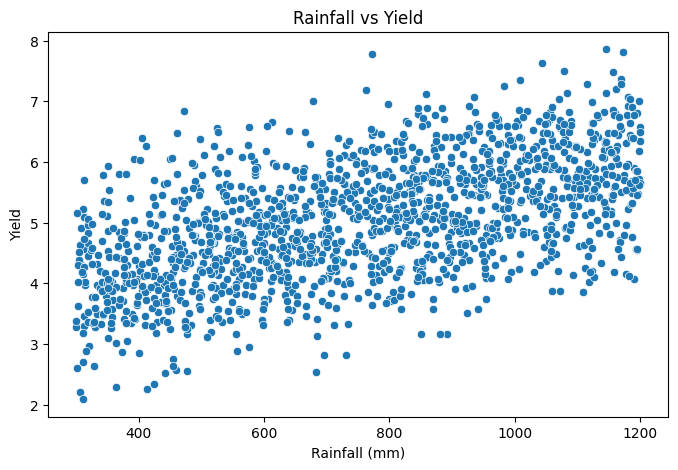

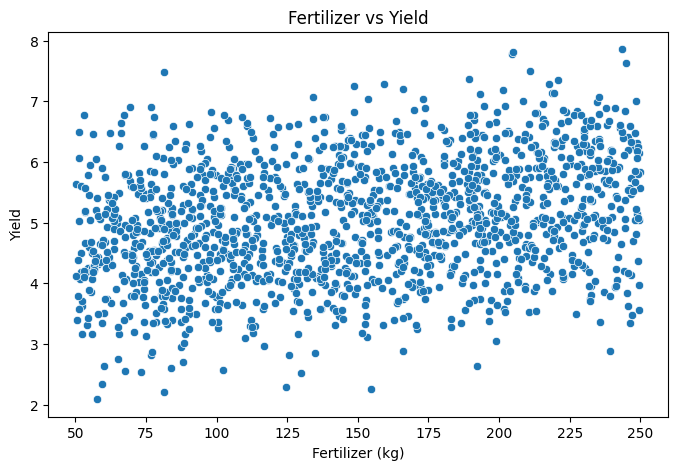

In [40]:
# Q8. Scatter Plot Analysis
#scatter plot for rainfall_mm vs yield_ton_per_hectare
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='rainfall_mm',
    y='yield_ton_per_hectare'
)

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield")

# scatter plot for fertilizer_kg vs yield_ton_per_hectare
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='fertilizer_kg',
    y='yield_ton_per_hectare'
)

plt.title("Fertilizer vs Yield")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Yield")

plt.show()

Rainfall appears to have a stronger relationship with yield because its correlation with yield is higher.

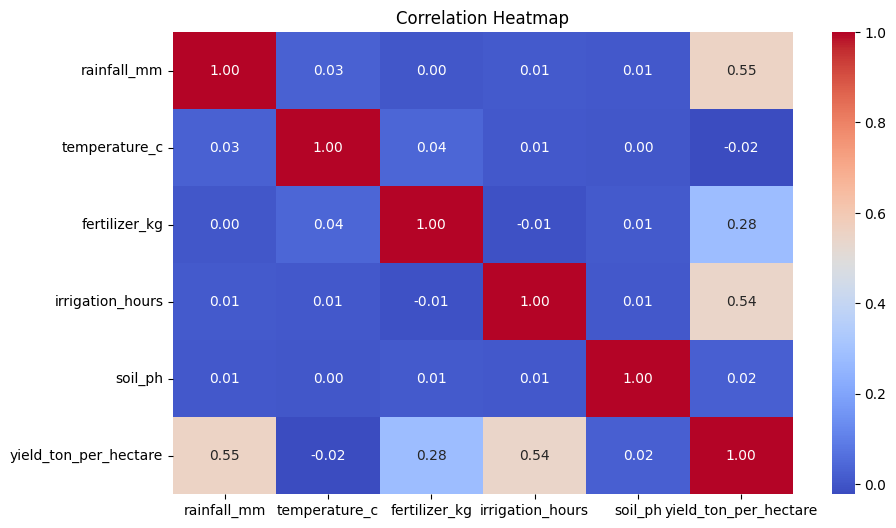

In [41]:
#Q9. Correlation Analysis
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

Top 3 Features Most Correlated with Yield
rainfall_mm (0.554)
irrigation_hours (0.543)
fertilizer_kg (0.278)

  crop_type  yield_ton_per_hectare
0    Cotton               4.607299
1     Maize               4.897143
2      Rice               5.494744
3   Soybean               5.173431
4     Wheat               4.989472
  soil_type  yield_ton_per_hectare
0      Clay               5.134326
1     Loamy               5.366519
2     Sandy               4.588882


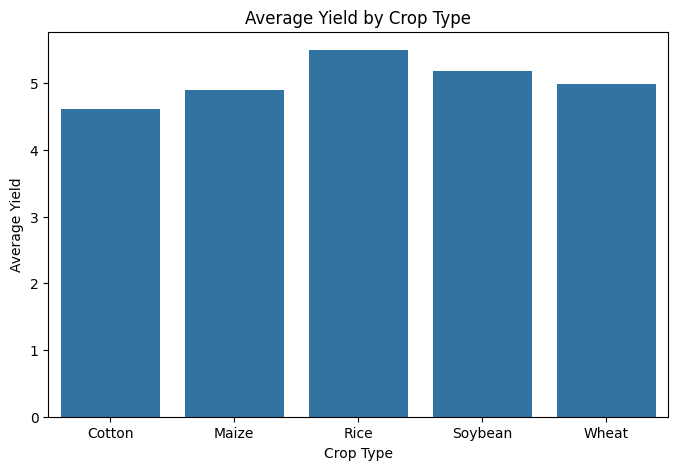

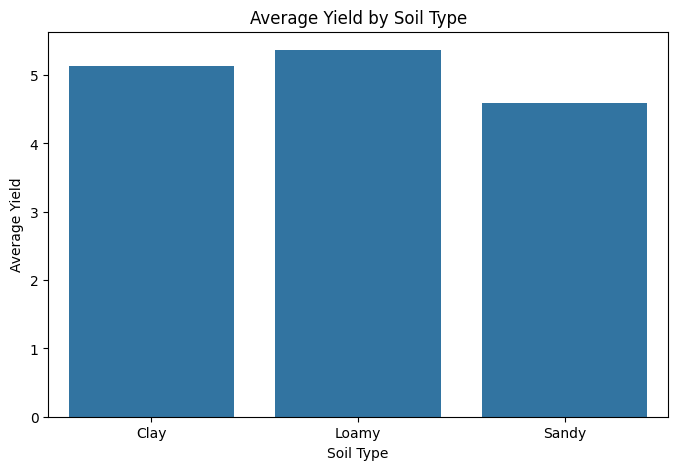

In [42]:
# Q10. Group-Based Analysis
crop_yield = df.groupby(
    'crop_type'
)['yield_ton_per_hectare'].mean().reset_index()

print(crop_yield)

plt.figure(figsize=(8,5))

sns.barplot(
    data=crop_yield,
    x='crop_type',
    y='yield_ton_per_hectare'
)

plt.title("Average Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield")


soil_yield = df.groupby(
    'soil_type'
)['yield_ton_per_hectare'].mean().reset_index()

print(soil_yield)

plt.figure(figsize=(8,5))

sns.barplot(
    data=soil_yield,
    x='soil_type',
    y='yield_ton_per_hectare'
)

plt.title("Average Yield by Soil Type")
plt.xlabel("Soil Type")
plt.ylabel("Average Yield")

plt.show()

In [43]:
# Part C: Data Preparation
# Q11. Feature Encoding

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['crop_type', 'soil_type'],
    drop_first=True
)

print("\nFirst 5 Rows of Encoded Dataset:")
print(df_encoded.head())

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')

First 5 Rows of Encoded Dataset:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False   

In [47]:
# Q12. Feature Selection

# Input Features
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

# Target Variable is yield_ton_per_hectare
y = df_encoded['yield_ton_per_hectare']

print("Input Features (X):")
print(X.columns)

print("\nTarget Variable (y):")
print(y.name)

Input Features (X):
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean',
       'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy'],
      dtype='object')

Target Variable (y):
yield_ton_per_hectare


In [45]:
# Q13. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1200, 11)
X_test Shape : (300, 11)
y_train Shape: (1200,)
y_test Shape : (300,)


In [46]:
# Q14. Linear Regression Model

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Intercept
print("Intercept:")
print(model.intercept_)

# Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nModel Coefficients:")
print(coefficients)

# Feature with highest positive coefficient
highest = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature with Highest Positive Coefficient:")
print(highest.iloc[0])

Intercept:
1.587132027736121

Model Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object


Feature with Highest Positive Coefficient was crop type as rice